# S&P 500 Stock Screener

This project builds a full end-to-end stock screening pipeline using real market data, structured storage, and interactive visualisation. It is broken down into three steps:

1. **Python Screener** — We use `yfinance` and `pandas` to pull financial data for all 503 S&P 500 companies, enrich it with custom metrics, and save it as a CSV.
2. **SQL Layer** — We load the screener data into a local SQLite database and run four targeted queries to surface stocks matching different investment strategies: value, income, growth, and deep value.
3. **Power BI Dashboard** — We connect Power BI to the SQLite database via an ODBC driver and build a four-panel interactive dashboard to visualise the screener results.

**Tools & Libraries:** Python, pandas, numpy, yfinance, matplotlib, sqlite3, Power BI Desktop

**Data Source:** S&P 500 constituent list from [datasets/s-and-p-500-companies](https://github.com/datasets/s-and-p-500-companies) · Financial data from [Yahoo Finance](https://finance.yahoo.com) via yfinance

## Step 1: Building the screener in Python (yfinance + pandas)

### Installing dependencies
We install `yfinance`, the core library for pulling stock data from Yahoo Finance.

In [ ]:
pip install yfinance -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Importing libraries & setting up the data directory
We import the necessary libraries and create a local `data/` folder to store our CSV and database files.

In [21]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import os
import requests
import io
from datetime import datetime

data_directory = os.getcwd() + "/data/"  # creating a data folder
os.makedirs(data_directory, exist_ok=True)

### Loading the S&P 500 stock universe
We load the S&P 500 company list from a local CSV file. This gives us the 500 tickers we will screen through. The CSV was sourced from [datasets/s-and-p-500-companies](https://github.com/datasets/s-and-p-500-companies).

In [17]:
stocks = pd.read_csv(data_directory + "sp500.csv")
stocks = stocks[["Symbol", "Security", "GICS Sector", "GICS Sub-Industry"]]
stocks.columns = ["Ticker", "Name", "Sector", "Industry"]
print(f"Loaded {len(stocks)} stocks")
print(stocks.head())

Loaded 503 stocks
  Ticker                 Name                  Sector  \
0    MMM                   3M             Industrials   
1    AOS          A. O. Smith             Industrials   
2    ABT  Abbott Laboratories             Health Care   
3   ABBV               AbbVie             Health Care   
4    ACN            Accenture  Information Technology   

                         Industry  
0        Industrial Conglomerates  
1               Building Products  
2           Health Care Equipment  
3                   Biotechnology  
4  IT Consulting & Other Services  


### Fetching sample stock data with yfinance
Before running the full screener, we test our data pipeline on 3 well-known stocks — AAPL, MSFT, and TSLA. We pull 1 month of closing prices and key fundamentals (market cap, P/E ratio) and plot the price history.

Closing Prices:
                                  AAPL        MSFT        TSLA
Date                                                         
2026-02-23 00:00:00-05:00  266.179993  384.470001  399.829987
2026-02-24 00:00:00-05:00  272.140015  389.000000  409.380005
2026-02-25 00:00:00-05:00  274.230011  400.600006  417.399994
2026-02-26 00:00:00-05:00  272.950012  401.720001  408.579987
2026-02-27 00:00:00-05:00  264.179993  392.739990  402.510010
2026-03-02 00:00:00-05:00  264.720001  398.549988  403.320007
2026-03-03 00:00:00-05:00  263.750000  403.929993  392.429993
2026-03-04 00:00:00-05:00  262.519989  405.200012  405.940002
2026-03-05 00:00:00-05:00  260.290009  410.679993  405.549988
2026-03-06 00:00:00-05:00  257.459991  408.959991  396.730011
2026-03-09 00:00:00-04:00  259.880005  409.410004  398.679993
2026-03-10 00:00:00-04:00  260.829987  405.760010  399.239990
2026-03-11 00:00:00-04:00  260.809998  404.880005  407.820007
2026-03-12 00:00:00-04:00  255.759995  401.859985  39

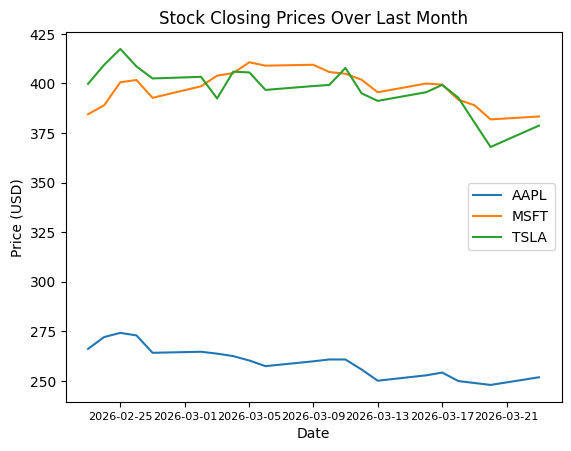

In [19]:
tickers = ['AAPL', 'MSFT', 'TSLA']
stock_data = {}
fundamentals = []
for ticker in tickers:
    stock = yf.Ticker(ticker)
    hist = stock.history(period="1mo")
    stock_data[ticker] = hist
    info = stock.info
    fundamentals.append({
        'Ticker': ticker,
        'Current Price': hist['Close'].iloc[-1],
        'Market Cap': info.get("marketCap", "N/A"),
        'P/E Ratio': info.get("trailingPE", "N/A")
    })
close_prices = pd.DataFrame({ticker: data['Close'] for ticker, data in stock_data.items()})
fundamentals_df = pd.DataFrame(fundamentals)
print("Closing Prices:\n", close_prices)
print("Fundamentals:\n", fundamentals_df)
plt.plot(close_prices)
plt.title("Stock Closing Prices Over Last Month")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.xticks(fontsize=8)
plt.legend(tickers)
plt.show()

### Fetching fundamental data for all S&P 500 stocks
We loop through all 503 tickers and use `yf.Ticker().info` to pull a rich set of financial metrics for each stock — including P/E ratio, market cap, dividend yield, revenue growth, price-to-book, and more. This forms the core of our screener dataset.

In [20]:
yf_info = []

for index, row in stocks.iterrows():
    try:
        ticker = yf.Ticker(row["Ticker"])
        yf_info.append(ticker.info)
    except Exception as e:
        print(f'Something went wrong with symbol {row["Ticker"]} with error {e}')

screener = pd.DataFrame(yf_info)

In [22]:
screener.head()

,address1,city,state,zip,country,phone,website,industry,industryKey,industryDisp,...,averageAnalystRating,cryptoTradeable,trailingPegRatio,displayName,address2,fax,ipoExpectedDate,prevName,nameChangeDate,industrySymbol
0,3M Center,Saint Paul,MN,55144-1000,United States,651 733 1110,https://www.3m.com,Conglomerates,conglomerates,Conglomerates,...,2.1 - Buy,False,1.3797,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,11270 West Park Place,Milwaukee,WI,53224,United States,414 359 4000,https://www.aosmith.com,Specialty Industrial Machinery,specialty-industrial-machinery,Specialty Industrial Machinery,...,2.6 - Hold,False,1.3269,A. O. Smith,NaN,NaN,NaN,NaN,NaN,NaN
2,100 Abbott Park Road,Abbott Park,IL,60064-6400,United States,224 667 6100,https://www.abbott.com,Medical Devices,medical-devices,Medical Devices,...,1.7 - Buy,False,1.5219,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1 North Waukegan Road,North Chicago,IL,60064-6400,United States,847 932 7900,https://www.abbvie.com,Drug Manufacturers - General,drug-manufacturers-general,Drug Manufacturers - General,...,1.9 - Buy,False,0.4860,AbbVie,NaN,NaN,NaN,NaN,NaN,NaN
4,1 Grand Canal Square,Dublin,NaN,D02 P820,Ireland,353 1 646 2000,https://www.accenture.com,Information Technology Services,information-technology-services,Information Technology Services,...,1.9 - Buy,False,1.5473,Accenture,Grand Canal Harbour,353 1 646 2020,NaN,NaN,NaN,NaN


### Categorising stocks by market capitalisation
We create a new column `CapCategory` that classifies each stock into one of six size buckets — nano, micro, small, mid, large, and mega — based on its market cap.

In [23]:
# define the bins and labels for each capitalization category
bins = [0, 50_000_000, 300_000_000, 2_000_000_000, 10_000_000_000, 200_000_000_000, float('inf')]
labels = ['nano', 'micro', 'small', 'mid', 'large', 'mega']

# create a new column with the categorized values
screener['CapCategory'] = pd.cut(screener['marketCap'], bins=bins, labels=labels, right=False)

### Calculating 52-week price position
We add a `52WeeksCurrentPosition` column that shows where the current price sits relative to its 52-week high and low. A value of 0 means it's at its 52-week low, and 1 means it's at its 52-week high. This helps identify momentum and potential entry points.

In [24]:
screener['52WeeksCurrentPosition'] = (screener['currentPrice'] - screener['fiftyTwoWeekLow']) / (screener['fiftyTwoWeekHigh'] -screener['fiftyTwoWeekLow'])

### Extracting company officer data
We parse the `companyOfficers` field from yfinance to extract two new columns — the total number of officers and their average age. This adds a governance dimension to the screener.

In [25]:
def get_company_officers(row):
    # we check in case is not a list to return NaN and not throw an error
    if not isinstance(row['companyOfficers'], list):
        return None, None
    return len(row['companyOfficers']), round(np.mean([obj['age'] for obj in row['companyOfficers'] if 'age' in obj and obj['age'] is not None]), 2)
    
screener[['CountOfCompanyOfficers','AvgAgeOfCompanyOfficers']] = screener.apply(lambda row: pd.Series(get_company_officers(row)), axis=1)

c:\Users\veral\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\veral\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


### Saving the screener to CSV
We save the enriched screener dataframe as a timestamped CSV file in the `data/` folder. The timestamp in the filename ensures previous runs are never overwritten.

In [26]:
formatted_datetime = datetime.now().strftime('%Y%m%d%H%M')
screener.to_csv(f'{data_directory}{formatted_datetime} Custom Screener.csv')

## Step 2: Adding an SQL layer

### Connecting to the SQLite database
We load our screener CSV back into a dataframe and write it into a local SQLite database file (`stocks.db`). This adds a proper SQL layer on top of our data, allowing us to run structured queries.
> **Note:** We print the data directory contents to confirm the CSV filename before loading it into SQLite.

In [29]:
import sqlite3
print(os.listdir(data_directory)[0])

202603232359 Custom Screener.csv


In [30]:
# loading my CSV from Step 1
screener = pd.read_csv(data_directory + os.listdir(data_directory)[0])

# create a SQLite database file
conn = sqlite3.connect(data_directory + "stocks.db")
screener.to_sql("stocks", conn, if_exists="replace", index=False)
print(f"Done! Written {len(screener)} rows to stocks.db")

Done! Written 503 rows to stocks.db


### Query 1: Value stocks: low P/E with large market cap
Screens for stocks with a P/E ratio under 20 and a market cap above $10B, sorted by lowest P/E first. These are potentially undervalued large-cap companies.

In [31]:
# Query 1: top 10 stocks by P/E ratio under 20 with market cap over $10B
query1 = """
    SELECT symbol, shortName, sector, trailingPE, marketCap
    FROM stocks
    WHERE trailingPE < 20
    AND trailingPE > 0
    AND marketCap > 10000000000
    ORDER BY trailingPE ASC
    LIMIT 10
"""
df_query1 = pd.read_sql(query1, conn)
print("Top 10 stocks by P/E under 20 with market cap > $10B")
print(df_query1)

Top 10 stocks by P/E under 20 with market cap > $10B
  symbol                        shortName                  sector  trailingPE  \
0  CMCSA              Comcast Corporation  Communication Services    5.377551   
1    ALL       Allstate Corporation (The)      Financial Services    5.451655   
2   CHTR     Charter Communications, Inc.  Communication Services    5.935101   
3    EIX             Edison International               Utilities    6.144589   
4    HPQ                          HP Inc.              Technology    6.958334   
5    SYF              Synchrony Financial      Financial Services    7.248922   
6   SOLV            Solventum Corporation              Healthcare    7.459459   
7    GIS              General Mills, Inc.      Consumer Defensive    8.076430   
8   ACGL          Arch Capital Group Ltd.      Financial Services    8.091810   
9    UHS  Universal Health Services, Inc.              Healthcare    8.175108   

      marketCap  
0  1.056183e+11  
1  5.385109e+10  
2

### Query 2: Income stocks: high dividend yield
Screens for stocks with a dividend yield above 3%, sorted highest first. Useful for income-focused investors looking for regular cash returns.

In [32]:
# Query 2: high dividend yield stocks (above 3%)
query2 = """
    SELECT symbol, shortName, sector, dividendYield, marketCap
    FROM stocks
    WHERE dividendYield > 0.03
    ORDER BY dividendYield DESC
    LIMIT 10
"""

df_query2 = pd.read_sql(query2, conn)
print("\nTop 10 High Dividend Yield Stocks (>3%)")
print(df_query2)


Top 10 High Dividend Yield Stocks (>3%)
  symbol                        shortName              sector  dividendYield  \
0    CAG             ConAgra Brands, Inc.  Consumer Defensive           9.23   
1    ARE  Alexandria Real Estate Equities         Real Estate           8.61   
2    KHC          The Kraft Heinz Company  Consumer Defensive           7.42   
3    CPB           The Campbell's Company  Consumer Defensive           7.40   
4    DOC      Healthpeak Properties, Inc.         Real Estate           7.16   
5    UPS      United Parcel Service, Inc.         Industrials           6.84   
6   AMCR                        Amcor plc   Consumer Cyclical           6.79   
7    PGR    Progressive Corporation (The)  Financial Services           6.75   
8   VICI             VICI Properties Inc.         Real Estate           6.64   
9    GIS              General Mills, Inc.  Consumer Defensive           6.59   

      marketCap  
0  7.412335e+09  
1  8.434529e+09  
2  2.519956e+10  
3  6.2

### Query 3: Growth stocks: strong revenue growth
Screens for stocks with revenue growth above 10%, sorted highest first. These are companies growing their top line aggressively.

In [33]:
# Query 3: stocks with strong revenue growth by sector
query3 = """
    SELECT symbol, shortName, sector, revenueGrowth, marketCap
    FROM stocks
    WHERE revenueGrowth > 0.1
    ORDER BY revenueGrowth DESC
    LIMIT 10
"""
df_query3 = pd.read_sql(query3, conn)
print("\nTop 10 Stocks by Revenue Growth (>10%)")
print(df_query3)


Top 10 Stocks by Revenue Growth (>10%)
  symbol                        shortName              sector  revenueGrowth  \
0     MU          Micron Technology, Inc.          Technology          1.963   
1    OXY  Occidental Petroleum Corporatio              Energy          1.489   
2    KEY                          KeyCorp  Financial Services          1.315   
3   SMCI       Super Micro Computer, Inc.          Technology          1.234   
4    APO  Apollo Global Management, Inc.   Financial Services          0.877   
5    KKR                   KKR & Co. Inc.  Financial Services          0.763   
6     BG                    Bunge Limited  Consumer Defensive          0.755   
7   NVDA               NVIDIA Corporation          Technology          0.732   
8   PLTR       Palantir Technologies Inc.          Technology          0.700   
9   AMCR                        Amcor plc   Consumer Cyclical          0.681   

      marketCap  
0  4.550294e+11  
1  5.885546e+10  
2  2.160989e+10  
3  1.29

### Query 4: Deep value stocks: low price-to-book ratio
Screens for stocks with a price-to-book ratio between 0 and 1.5, sorted lowest first. A low P/B ratio can indicate a stock is trading below its intrinsic asset value.

In [34]:
# Query 4: Undervalued stocks (low P/B ratio)
query4 = """
    SELECT symbol, shortName, sector, priceToBook, trailingPE, marketCap
    FROM stocks
    WHERE priceToBook < 1.5
    AND priceToBook > 0
    ORDER BY priceToBook ASC
    LIMIT 10
"""
df_query4 = pd.read_sql(query4, conn)
print("\nTop 10 Undervalued Stocks by Price-To-Book (<1.5)")
print(df_query4)

conn.close()


Top 10 Undervalued Stocks by Price-To-Book (<1.5)
  symbol                        shortName                  sector  \
0    ARE  Alexandria Real Estate Equities             Real Estate   
1    KHC          The Kraft Heinz Company      Consumer Defensive   
2    MOS             Mosaic Company (The)         Basic Materials   
3    GPN             Global Payments Inc.             Industrials   
4    TAP    Molson Coors Beverage Company      Consumer Defensive   
5    CNC              Centene Corporation              Healthcare   
6     EG              Everest Group, Ltd.      Financial Services   
7   PSKY   Paramount Skydance Corporation  Communication Services   
8    CAG             ConAgra Brands, Inc.      Consumer Defensive   
9    TFC     Truist Financial Corporation      Financial Services   

   priceToBook  trailingPE     marketCap  
0     0.536527         NaN  8.434529e+09  
1     0.604962         NaN  2.519956e+10  
2     0.625624   14.011765  7.562975e+09  
3     0.721953   

## Step 3: Connecting to Power BI & building a dashboard

The `stocks.db` SQLite database is connected to Power BI Desktop via an ODBC driver. Four table visuals are built — one for each SQL query — and arranged into a single-page dashboard titled **"S&P 500 Stock Screener Dashboard"**.

The dashboard allows users to visually explore:
- Value stocks (low P/E, large cap)
- Income stocks (high dividend yield)
- Growth stocks (high revenue growth)
- Deep value stocks (low price-to-book)